<a href="https://colab.research.google.com/github/ka-means/adaptive-autonomy-lab/blob/main/01_information_disagreement_autonomous_teams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Information disagreement in autonomous teams

## When agreement is not enough

A team of autonomous agents can agree for the wrong reasons.

That is the problem I isolate in this notebook. Three agents observe the same changing environment, but they do not necessarily see the same moment, their errors are not always independent, and the confidence they report is not always a good description of their actual reliability.

The question is deliberately narrow:

> **When does agreement stop being useful evidence that the team is correct?**

The model is intentionally small. There is one dynamic state, three agents, and one binary team decision. I am not trying to reproduce a complete robotic mission. I want enough structure to separate three mechanisms that are easily hidden inside a larger system:

- **stale information:** an agent is reasoning from an older state of the environment;
- **correlated errors:** several agents can be wrong for the same underlying reason;
- **miscalibrated confidence:** a source can report more certainty than its actual performance justifies.

The notebook also separates stationary experiments from a genuine change in environment dynamics. That distinction matters because a system can disagree either because its information is poor or because the world itself has changed.


## Literature context

The mechanisms studied here are grounded in established work rather than introduced as new phenomena.

**Information freshness.** The Age of Information literature shows that having information and having *current* information are not the same thing. I use a simpler quantity here: fixed observation age. It captures how old an observation is without modelling queues, scheduling, or packet arrivals.

**Distributed fusion.** Consensus and sensor-fusion research studies how distributed estimates can be combined. That literature also makes clear that agreement is only useful when the structure behind the estimates is understood.

**Unknown dependence.** Covariance Intersection and related work address the problem of combining estimates when their error dependence is not known well enough. This notebook does not implement Covariance Intersection; it uses a controlled common-error parameter to make the problem visible.

**Calibration.** A confidence value is useful only if it is reasonably aligned with empirical correctness. The calibration experiment separates actual observation quality from reported uncertainty.

**Agreement under change.** Mesto and Cruz study a related failure in multi-teacher reinforcement learning, where low disagreement can coexist with poor performance when outdated expertise is amplified by the aggregation mechanism. I do not reproduce their reinforcement-learning experiment here. I use a simpler state-sharing model to study a related information problem.

### References

- Yates, R. D., Sun, Y., Brown, D. R., Kaul, S. K., Modiano, E., & Ulukus, S. (2021). *Age of Information: An Introduction and Survey*. IEEE JSAC, 39(5), 1183–1210. DOI: `10.1109/JSAC.2021.3065072`.
- Olfati-Saber, R., & Shamma, J. S. (2005). *Consensus Filters for Sensor Networks and Distributed Sensor Fusion*. DOI: `10.1109/CDC.2005.1583238`.
- Julier, S. J., & Uhlmann, J. K. (1997). *A Non-divergent Estimation Algorithm in the Presence of Unknown Correlations*. DOI: `10.1109/ACC.1997.609105`.
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On Calibration of Modern Neural Networks*. ICML, PMLR 70.
- Mesto, M., & Cruz, F. (2026). *The Consensus Paradox: When Low Disagreement Leads to Catastrophic Failure in Multi-teacher Reinforcement Learning*. DOI: `10.1007/978-981-95-4972-6_33`.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.stats import t as student_t

BASE_SEED = 20260915
N_RUNS = 100

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 50)


## 1. Experimental design

The environment is represented by one value that changes over time. The sign of that value determines the correct team action.

Most experiments are stationary. That is deliberate: when I change observation age, error dependence, or confidence calibration, I want that mechanism to be the main thing changing.

The change-of-regime experiment is treated separately.

Three agents observe the environment. They can differ in four ways:

- the age of the observation they hold;
- the noise affecting that observation;
- how much of the error is shared with other agents;
- the uncertainty they report.

The simulation uses a fixed seed policy and 100 independent trajectories for each experimental condition. Confidence intervals are calculated across complete trajectories, not across individual time steps.


In [ ]:
@dataclass(frozen=True)
class ExperimentConfig:
    T: int = 700
    persistence_before: float = 0.96
    persistence_after: float = 0.45
    process_noise_before: float = 0.22
    obs_noise: float = 0.30
    error_correlation: float = 0.0
    delays: tuple = (0, 3, 3)
    calibration_factors: tuple = (1.0, 1.0, 1.0)
    threshold: float = 0.0
    regime_change: bool = False
    change_step: int = 350
    seed: int = BASE_SEED


## 2. Environment dynamics

The state follows a simple autoregressive process. In plain terms, the next state depends partly on the previous one plus a random disturbance.

For the stationary experiments, the dynamics remain unchanged for the full run.

For the regime-change experiment, the persistence of the environment is reduced after the change point. A lower persistence means that old states become less informative about what happens next.

There is an important control in the implementation: when persistence changes, the process noise is rescaled so that the long-run variance of the state remains approximately the same. Without that correction, changing persistence would also change the overall amplitude of the signal and therefore alter the signal-to-noise ratio. I want the regime experiment to change temporal predictability, not quietly change several properties at once.


In [ ]:
def process_noise_after_change(cfg):
    target_var = (
        cfg.process_noise_before ** 2
        / (1.0 - cfg.persistence_before ** 2)
    )
    return float(
        np.sqrt(
            target_var
            * (1.0 - cfg.persistence_after ** 2)
        )
    )


def simulate_environment(cfg):
    rng = np.random.default_rng(cfg.seed)
    x = np.zeros(cfg.T)

    sigma_after = process_noise_after_change(cfg)

    for t in range(1, cfg.T):
        if cfg.regime_change and t >= cfg.change_step:
            persistence = cfg.persistence_after
            process_noise = sigma_after
        else:
            persistence = cfg.persistence_before
            process_noise = cfg.process_noise_before

        x[t] = (
            persistence * x[t - 1]
            + rng.normal(0.0, process_noise)
        )

    return x


## 3. Local observations

An agent with an observation age of four steps is using a measurement generated four steps earlier. I call these **local estimates**, not formal Bayesian beliefs: there is no Kalman filter or Bayesian belief update in this notebook.

Observation error has two parts:

- a **private component**, which affects only one agent;
- a **shared component**, which pushes several agents in the same direction.

The shared component is how I create controlled error dependence.

The measurement noise is attached to the time at which the observation was actually generated. If an agent is carrying an old observation, it carries the old measurement and its old measurement error together.


In [ ]:
def simulate_agents(cfg, x):
    rng = np.random.default_rng(cfg.seed + 10_000)
    n_agents = len(cfg.delays)
    time = np.arange(cfg.T)

    rho = float(
        np.clip(cfg.error_correlation, 0.0, 1.0)
    )

    common_noise = rng.normal(
        0.0, 1.0, size=cfg.T
    )
    private_noise = rng.normal(
        0.0, 1.0, size=(cfg.T, n_agents)
    )

    observations = np.zeros(
        (cfg.T, n_agents)
    )
    ages = np.zeros(
        (cfg.T, n_agents),
        dtype=int,
    )
    reported_sigma = np.zeros(
        (cfg.T, n_agents)
    )

    for i, delay in enumerate(cfg.delays):
        source_t = np.maximum(
            0, time - delay
        )

        shared = (
            np.sqrt(rho)
            * common_noise[source_t]
        )
        private = (
            np.sqrt(1.0 - rho)
            * private_noise[source_t, i]
        )

        measurement_noise = (
            cfg.obs_noise
            * (shared + private)
        )

        observations[:, i] = (
            x[source_t]
            + measurement_noise
        )
        ages[:, i] = time - source_t

        reported_sigma[:, i] = (
            cfg.obs_noise
            * cfg.calibration_factors[i]
        )

    return (
        observations,
        ages,
        reported_sigma,
    )


## 4. Fusion rules

I compare several simple ways of turning local information into a team estimate or team action.

**Mean over all sources.** Every source receives the same weight.

**Freshest random.** The team uses one of the sources with the minimum observation age. If several sources are equally fresh, the tie is broken uniformly using a reproducible random generator. This removes the deterministic preference for Agent A that would result from using `argmin`.

**Freshest subset mean.** Instead of selecting one source, the team averages only across the sources tied for minimum observation age. This keeps redundancy when several equally current observations are available but ignores older observations.

**Inverse variance.** Sources reporting less uncertainty receive more weight.

**Majority vote.** Each agent converts its local estimate into a binary action and the numerical majority wins.

**Oracle reliability.** The source weights are estimated using historical error against the true state during a calibration period. This method is not deployable as written because it uses privileged ground truth. It is kept separate as a reference rather than presented as a competing operational strategy.


In [ ]:
def fuse_mean(obs):
    return np.mean(obs, axis=1)


def fuse_freshest_random(
    obs,
    ages,
    seed,
):
    rng = np.random.default_rng(
        seed + 100_000
    )

    min_age = ages.min(
        axis=1,
        keepdims=True,
    )
    candidates = ages == min_age

    scores = rng.random(obs.shape)
    scores[~candidates] = np.inf

    idx = np.argmin(
        scores,
        axis=1,
    )

    return obs[
        np.arange(obs.shape[0]),
        idx,
    ]


def fuse_freshest_subset_mean(
    obs,
    ages,
):
    min_age = ages.min(
        axis=1,
        keepdims=True,
    )
    mask = ages == min_age

    return (
        np.sum(obs * mask, axis=1)
        / np.sum(mask, axis=1)
    )


def fuse_inverse_variance(
    obs,
    reported_sigma,
):
    precision = (
        1.0
        / np.maximum(
            reported_sigma,
            1e-8,
        ) ** 2
    )

    weights = (
        precision
        / precision.sum(
            axis=1,
            keepdims=True,
        )
    )

    return np.sum(
        weights * obs,
        axis=1,
    )


def estimate_oracle_reliability_weights(
    obs,
    x,
    calibration_end,
):
    errors = (
        obs[:calibration_end]
        - x[:calibration_end, None]
    )

    mse = np.mean(
        errors ** 2,
        axis=0,
    )

    inverse_mse = (
        1.0
        / np.maximum(mse, 1e-8)
    )

    return (
        inverse_mse
        / inverse_mse.sum()
    )


def fuse_oracle_reliability(
    obs,
    x,
    calibration_end=175,
):
    weights = (
        estimate_oracle_reliability_weights(
            obs,
            x,
            calibration_end,
        )
    )

    return (
        np.sum(
            obs * weights[None, :],
            axis=1,
        ),
        weights,
    )


def majority_action(
    obs,
    threshold=0.0,
):
    local_actions = (
        obs > threshold
    ).astype(int)

    votes = local_actions.sum(
        axis=1
    )

    team_action = (
        votes
        >= (
            obs.shape[1] // 2
            + 1
        )
    ).astype(int)

    return (
        team_action,
        local_actions,
    )


## 5. Metrics

I separate four different questions.

**How close is the numerical estimate to the real state?**  
This is measured with RMSE.

**How often does the team select the correct action?**  
This is decision accuracy.

**How far apart are the agents from each other?**  
This is cross-agent dispersion. Low dispersion means the sources are similar. It says nothing about whether they are right.

**What does unanimity actually mean?**  
I keep three consensus quantities:

- **unanimity rate:** how often all three agents choose the same action;
- **joint false consensus:** how often the team is both unanimous and wrong;
- **conditional false consensus:** when the team is unanimous, how often that unanimous decision is wrong.

The distinction matters. A system that is rarely unanimous but often wrong when it is unanimous is different from a system that is almost always unanimous with a smaller conditional error rate.


In [ ]:
def rmse(est, x):
    return float(
        np.sqrt(
            np.mean(
                (est - x) ** 2
            )
        )
    )


def decision_accuracy_from_estimate(
    est,
    x,
    threshold,
):
    return float(
        np.mean(
            (est > threshold)
            == (x > threshold)
        )
    )


def cross_agent_dispersion(obs):
    return float(
        np.mean(
            np.std(
                obs,
                axis=1,
            )
        )
    )


def consensus_metrics(
    local_actions,
    x,
    threshold,
):
    truth = (
        x > threshold
    ).astype(int)

    unanimous = np.all(
        local_actions
        == local_actions[:, [0]],
        axis=1,
    )

    unanimous_action = (
        local_actions[:, 0]
    )

    wrong = (
        unanimous_action != truth
    )

    unanimity_rate = float(
        np.mean(unanimous)
    )

    joint_false_consensus = float(
        np.mean(
            unanimous & wrong
        )
    )

    if unanimous.sum() > 0:
        conditional_false_consensus = float(
            np.sum(
                unanimous & wrong
            )
            / np.sum(unanimous)
        )
    else:
        conditional_false_consensus = np.nan

    return {
        "unanimity_rate": unanimity_rate,
        "joint_false_consensus": (
            joint_false_consensus
        ),
        "conditional_false_consensus": (
            conditional_false_consensus
        ),
    }


def run_once(cfg):
    x = simulate_environment(cfg)

    (
        obs,
        ages,
        reported_sigma,
    ) = simulate_agents(cfg, x)

    estimates = {
        "mean_all": fuse_mean(obs),
        "freshest_random": (
            fuse_freshest_random(
                obs,
                ages,
                cfg.seed,
            )
        ),
        "freshest_subset_mean": (
            fuse_freshest_subset_mean(
                obs,
                ages,
            )
        ),
        "inverse_variance": (
            fuse_inverse_variance(
                obs,
                reported_sigma,
            )
        ),
    }

    (
        oracle_estimate,
        oracle_weights,
    ) = fuse_oracle_reliability(
        obs,
        x,
        calibration_end=max(
            50,
            cfg.T // 4,
        ),
    )

    estimates[
        "oracle_reliability"
    ] = oracle_estimate

    (
        majority,
        local_actions,
    ) = majority_action(
        obs,
        cfg.threshold,
    )

    truth = (
        x > cfg.threshold
    ).astype(int)

    strategy_rows = []

    for name, est in estimates.items():
        strategy_rows.append({
            "strategy": name,
            "rmse": rmse(est, x),
            "decision_accuracy": (
                decision_accuracy_from_estimate(
                    est,
                    x,
                    cfg.threshold,
                )
            ),
        })

    strategy_rows.append({
        "strategy": "majority_vote",
        "rmse": np.nan,
        "decision_accuracy": float(
            np.mean(
                majority == truth
            )
        ),
    })

    team_metrics = {
        "cross_agent_dispersion": (
            cross_agent_dispersion(obs)
        ),
        **consensus_metrics(
            local_actions,
            x,
            cfg.threshold,
        ),
    }

    details = {
        "x": x,
        "obs": obs,
        "ages": ages,
        "reported_sigma": (
            reported_sigma
        ),
        "local_actions": (
            local_actions
        ),
        "majority": majority,
        "oracle_weights": (
            oracle_weights
        ),
        "estimates": estimates,
    }

    return (
        pd.DataFrame(
            strategy_rows
        ),
        team_metrics,
        details,
    )


## 6. Statistical summary

Every parameter setting is evaluated over 100 complete trajectories.

For each reported mean, I calculate a 95% confidence interval across those 100 trajectory-level results using a Student t interval. The time steps inside one trajectory are not treated as independent samples.

I also use the same run seeds across parameter values inside each sweep. This gives the different strategies comparable underlying trajectories rather than changing both the environment and the experimental condition at the same time.


In [ ]:
def summarize_ci(
    df,
    group_cols,
    value_col,
    confidence=0.95,
):
    summary = (
        df.groupby(group_cols)[value_col]
        .agg(
            ["mean", "count", "std"]
        )
        .reset_index()
    )

    alpha = 1.0 - confidence

    critical = summary[
        "count"
    ].apply(
        lambda n: student_t.ppf(
            1.0 - alpha / 2.0,
            df=max(int(n) - 1, 1),
        )
    )

    summary["ci95"] = (
        critical
        * summary["std"]
        / np.sqrt(
            summary["count"]
        )
    )

    return summary


## 7. Baseline

The baseline is stationary.

Agent A holds a current observation. Agents B and C are three steps behind. Errors are independent and all three agents report calibrated uncertainty.

This is not meant to represent a realistic deployment. It gives a fixed reference configuration before the individual mechanisms are varied.


In [ ]:
baseline_cfg = ExperimentConfig(
    regime_change=False,
    delays=(0, 3, 3),
    seed=BASE_SEED,
)

(
    baseline_strategy,
    baseline_team,
    baseline_details,
) = run_once(baseline_cfg)

display(
    baseline_strategy[
        baseline_strategy[
            "strategy"
        ] != "oracle_reliability"
    ]
)

display(
    pd.DataFrame(
        [baseline_team]
    )
)


,strategy,rmse,decision_accuracy
0,mean_all,0.302926,0.827143
1,freshest_random,0.287487,0.868571
2,freshest_subset_mean,0.287672,0.870000
3,inverse_variance,0.302926,0.827143
5,majority_vote,NaN,0.820000


,cross_agent_dispersion,unanimity_rate,joint_false_consensus,conditional_false_consensus
0,0.269557,0.64,0.035714,0.055804


### Reading the baseline

The operational strategies do not collapse into one answer. Even in this small setting, the result depends on what each rule considers valuable: redundancy, recency, reported uncertainty, or numerical majority.

The privileged oracle reference assigns approximately **0.63** of its weight to Agent A, compared with **0.20** and **0.17** to Agents B and C.

That does not mean Agent A is intrinsically a better sensor. The three agents use the same noise model. Agent A receives more oracle weight because it is current while B and C are delayed.

That distinction is central to the notebook: **source quality is not always a permanent property of the source. The same source can become more or less useful because the information it carries has changed.**


### Privileged oracle reference

The oracle is shown separately from the deployable baselines because it uses true-state information during calibration.

It is not an upper bound. Historical ground-truth calibration can still become a poor guide when conditions change. Its role is narrower: it provides a reference for how a reliability-aware weighting behaves when source error can be measured directly.


In [ ]:
baseline_strategy[
    baseline_strategy[
        "strategy"
    ] == "oracle_reliability"
]


,strategy,rmse,decision_accuracy
4,oracle_reliability,0.23998,0.882857


## 8. Experiment 1: When the majority becomes stale

For this experiment, the environment remains stationary.

Agent A always holds a current observation. Agents B and C are progressively moved further into the past.

Everything else remains fixed:

- observation noise does not change;
- source errors are independent;
- uncertainty is correctly calibrated.

Two recency-based rules are included.

`freshest_random` selects one of the most recent sources and breaks ties randomly but reproducibly.

`freshest_subset_mean` averages across all sources that share the minimum observation age.

This separates two questions that were previously mixed together: whether current information should be preferred, and whether redundancy should still be used when several equally current sources exist.


In [ ]:
delay_records = []

for delay in (
    0, 1, 3, 5, 8, 12
):
    for run in range(N_RUNS):
        cfg = ExperimentConfig(
            regime_change=False,
            delays=(0, delay, delay),
            error_correlation=0.0,
            obs_noise=0.30,
            calibration_factors=(
                1.0, 1.0, 1.0
            ),
            seed=BASE_SEED + run,
        )

        strategy_metrics, _, _ = (
            run_once(cfg)
        )

        strategy_metrics[
            "delay"
        ] = delay
        strategy_metrics[
            "run"
        ] = run

        delay_records.append(
            strategy_metrics
        )

delay_df = pd.concat(
    delay_records,
    ignore_index=True,
)

delay_summary = summarize_ci(
    delay_df,
    ["delay", "strategy"],
    "decision_accuracy",
)

display(delay_summary)


,delay,strategy,mean,count,std,ci95
0,0,freshest_random,0.880071,100,0.023633,0.004689
1,0,freshest_subset_mean,0.928829,100,0.016064,0.003188
2,0,inverse_variance,0.928829,100,0.016064,0.003188
3,0,majority_vote,0.918557,100,0.017155,0.003404
4,0,mean_all,0.928829,100,0.016064,0.003188
5,0,oracle_reliability,0.928829,100,0.016292,0.003233
6,1,freshest_random,0.880943,100,0.021061,0.004179
7,1,freshest_subset_mean,0.880814,100,0.021138,0.004194
8,1,inverse_variance,0.906714,100,0.018987,0.003768
9,1,majority_vote,0.896343,100,0.019923,0.003953


### Reading the table

The tie correction changes the interpretation of the zero-delay case.

When all three agents are equally current:

- averaging all sources reaches about **0.929** accuracy;
- averaging the freshest subset also reaches about **0.929**, because the freshest subset is the full team;
- selecting one fresh source at random reaches about **0.880**.

That is the behaviour I would expect. If several equally current sources have independent noise, throwing two of them away gives up useful redundancy.

Once B and C become stale, the structure changes. At a three-step delay:

- freshest-subset mean is about **0.881**;
- freshest-random is about **0.881**;
- mean over all three falls to about **0.874**;
- majority vote falls to about **0.859**.

At twelve steps, mean over all sources falls further to about **0.787**, while the two freshest rules remain around **0.881** and **0.881** because only Agent A is current.

The point is not that one fresh source is universally better than a team. At zero delay the opposite is true. The result is more specific:

> **Redundancy helps when the sources describe the same present. Redundancy becomes less useful when most of that redundancy is temporally misaligned.**


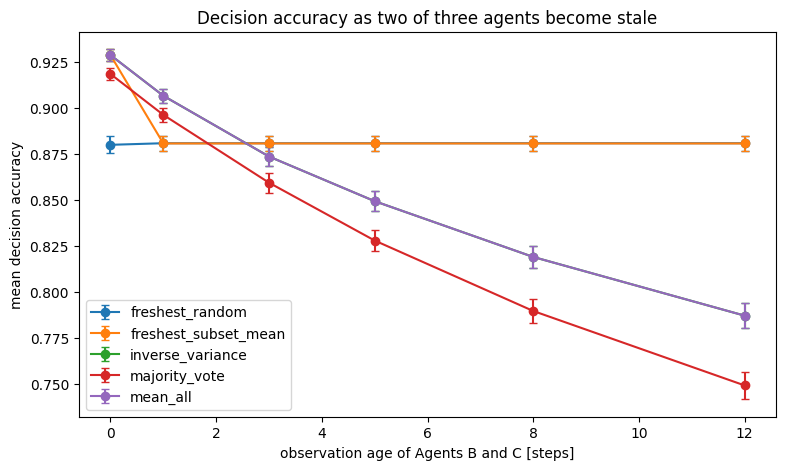

In [ ]:
deployable = delay_summary[
    delay_summary["strategy"].isin([
        "mean_all",
        "freshest_random",
        "freshest_subset_mean",
        "inverse_variance",
        "majority_vote",
    ])
]

plt.figure(figsize=(9, 5))

for strategy in deployable[
    "strategy"
].unique():
    subset = deployable[
        deployable["strategy"]
        == strategy
    ]

    plt.errorbar(
        subset["delay"],
        subset["mean"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=strategy,
    )

plt.xlabel(
    "observation age of Agents B and C [steps]"
)
plt.ylabel(
    "mean decision accuracy"
)
plt.title(
    "Decision accuracy as two of three agents become stale"
)
plt.legend()
plt.show()


### Reading the figure

The figure shows a crossover rather than a universal winner.

When every source is current, using all three observations is valuable. As B and C move further into the past, rules that keep treating all three observations as equally current deteriorate.

The recency-based rules do not improve with delay. They simply avoid importing the additional stale information.

This is an important distinction for autonomous coordination. A larger number of observations is not automatically a larger amount of current evidence.


### Oracle reference for Experiment 1

The oracle curve is kept outside the operational comparison because its calibration uses ground truth.


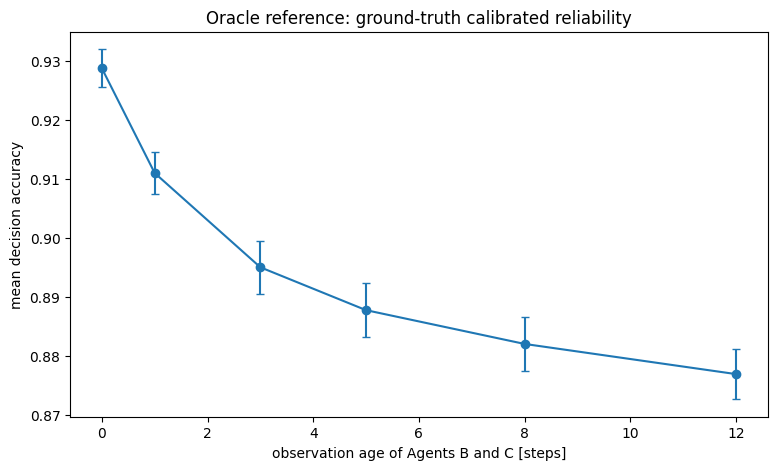

In [ ]:
oracle_delay = delay_summary[
    delay_summary[
        "strategy"
    ] == "oracle_reliability"
]

plt.figure(figsize=(9, 5))
plt.errorbar(
    oracle_delay["delay"],
    oracle_delay["mean"],
    yerr=oracle_delay["ci95"],
    marker="o",
    capsize=3,
)

plt.xlabel(
    "observation age of Agents B and C [steps]"
)
plt.ylabel(
    "mean decision accuracy"
)
plt.title(
    "Oracle reference: ground-truth calibrated reliability"
)
plt.show()


### What the oracle adds

The oracle adapts its fixed source weights to historical error, so it increasingly favours the current source as B and C become older.

That is useful as a reference, but it also exposes the limitation of a single reliability number. Historical reliability can tell us which source has performed better on average. It still does not explain *why* a source has become unreliable.


## 9. Experiment 2: When agreement comes from the same error

All three agents are current in this experiment. No source is stale.

The only thing that changes is error dependence.

At low correlation, most of the observation error is private to each agent. At high correlation, the same disturbance increasingly pushes all three agents in the same direction.

This is where agreement becomes ambiguous. Three agents can agree because they independently reached the same conclusion, or because they are all carrying the same mistake.


In [ ]:
corr_records = []
corr_team_records = []

for rho in (
    0.0, 0.2, 0.4,
    0.6, 0.8, 0.95
):
    for run in range(N_RUNS):
        cfg = ExperimentConfig(
            regime_change=False,
            delays=(0, 0, 0),
            error_correlation=rho,
            obs_noise=0.45,
            calibration_factors=(
                1.0, 1.0, 1.0
            ),
            seed=(
                BASE_SEED
                + 1_000
                + run
            ),
        )

        (
            strategy_metrics,
            team_metrics,
            _,
        ) = run_once(cfg)

        strategy_metrics[
            "rho"
        ] = rho
        strategy_metrics[
            "run"
        ] = run

        corr_records.append(
            strategy_metrics
        )

        corr_team_records.append({
            "rho": rho,
            "run": run,
            **team_metrics,
        })

corr_df = pd.concat(
    corr_records,
    ignore_index=True,
)

corr_team_df = pd.DataFrame(
    corr_team_records
)

corr_dispersion_summary = (
    summarize_ci(
        corr_team_df,
        ["rho"],
        "cross_agent_dispersion",
    )
)

corr_unanimity_summary = (
    summarize_ci(
        corr_team_df,
        ["rho"],
        "unanimity_rate",
    )
)

corr_joint_summary = (
    summarize_ci(
        corr_team_df,
        ["rho"],
        "joint_false_consensus",
    )
)

corr_conditional_summary = (
    summarize_ci(
        corr_team_df,
        ["rho"],
        "conditional_false_consensus",
    )
)

corr_majority_summary = (
    summarize_ci(
        corr_df[
            corr_df["strategy"]
            == "majority_vote"
        ],
        ["rho"],
        "decision_accuracy",
    )
)

display(corr_dispersion_summary)
display(corr_unanimity_summary)
display(corr_joint_summary)
display(corr_conditional_summary)
display(corr_majority_summary)


,rho,mean,count,std,ci95
0,0.00,0.326266,100,0.007408,0.001470
1,0.20,0.291821,100,0.006626,0.001315
2,0.40,0.252725,100,0.005739,0.001139
3,0.60,0.206349,100,0.004686,0.000930
4,0.80,0.145911,100,0.003313,0.000657
5,0.95,0.072955,100,0.001657,0.000329


,rho,mean,count,std,ci95
0,0.00,0.648129,100,0.043385,0.008609
1,0.20,0.688900,100,0.035598,0.007063
2,0.40,0.731786,100,0.032255,0.006400
3,0.60,0.781914,100,0.027757,0.005508
4,0.80,0.846571,100,0.019985,0.003965
5,0.95,0.923414,100,0.011500,0.002282


,rho,mean,count,std,ci95
0,0.00,0.019086,100,0.005883,0.001167
1,0.20,0.032543,100,0.008344,0.001656
2,0.40,0.047814,100,0.010186,0.002021
3,0.60,0.068700,100,0.012930,0.002566
4,0.80,0.097171,100,0.016925,0.003358
5,0.95,0.132714,100,0.020547,0.004077


,rho,mean,count,std,ci95
0,0.00,0.029842,100,0.010154,0.002015
1,0.20,0.047642,100,0.013380,0.002655
2,0.40,0.065736,100,0.015283,0.003032
3,0.60,0.088268,100,0.018351,0.003641
4,0.80,0.115051,100,0.021231,0.004213
5,0.95,0.143841,100,0.022901,0.004544


,rho,mean,count,std,ci95
0,0.00,0.879114,100,0.021704,0.004307
1,0.20,0.867629,100,0.021905,0.004346
2,0.40,0.856786,100,0.022134,0.004392
3,0.60,0.846729,100,0.023683,0.004699
4,0.80,0.838671,100,0.023761,0.004715
5,0.95,0.832529,100,0.023722,0.004707


### Reading the consensus metrics

The result is stronger when unanimity is separated from false consensus.

As shared-error correlation moves from 0 to 0.95:

- cross-agent dispersion falls from about **0.326** to **0.073**;
- unanimity rises from about **0.648** to **0.923**;
- majority-vote accuracy falls from about **0.879** to **0.833**;
- joint false consensus rises from about **0.019** to **0.133**;
- conditional false consensus rises from about **0.030** to **0.144**.

So two things are happening at once. The agents agree more often, and agreement itself becomes less trustworthy.

That distinction is the reason for keeping both false-consensus measures. Joint false consensus tells me how much of the entire mission timeline is occupied by unanimous errors. Conditional false consensus tells me the risk of trusting the team specifically at the moments when everyone agrees.


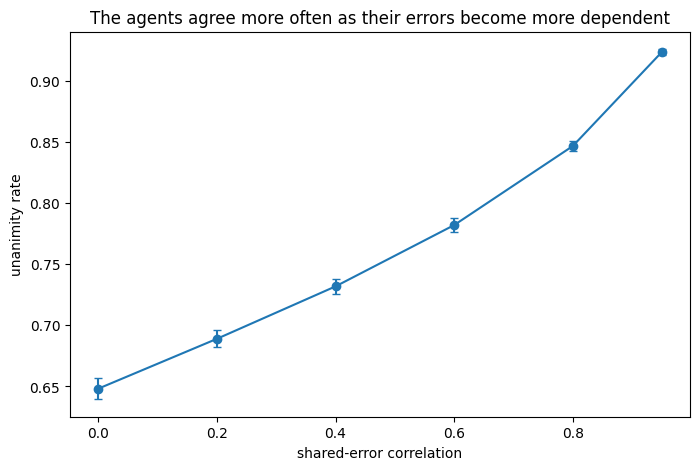

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    corr_unanimity_summary["rho"],
    corr_unanimity_summary["mean"],
    yerr=corr_unanimity_summary["ci95"],
    marker="o",
    capsize=3,
)

plt.xlabel(
    "shared-error correlation"
)
plt.ylabel(
    "unanimity rate"
)
plt.title(
    "The agents agree more often as their errors become more dependent"
)
plt.show()


### Reading the unanimity curve

More correlation produces more internal agreement.

On its own, that curve could look reassuring. The team appears more coherent and less divided.

But coherence is not the same thing as independent confirmation. If several agents are responding to the same underlying disturbance, their agreement may contain much less new information than the number of agreeing agents suggests.


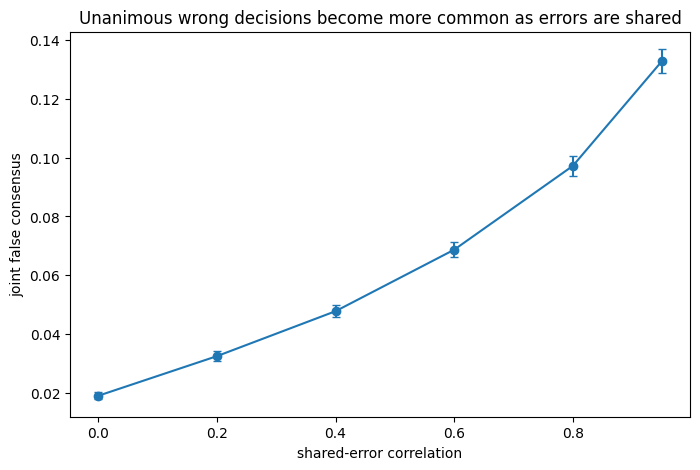

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    corr_joint_summary["rho"],
    corr_joint_summary["mean"],
    yerr=corr_joint_summary["ci95"],
    marker="o",
    capsize=3,
)

plt.xlabel(
    "shared-error correlation"
)
plt.ylabel(
    "joint false consensus"
)
plt.title(
    "Unanimous wrong decisions become more common as errors are shared"
)
plt.show()


### Reading joint false consensus

This curve answers a mission-level question:

> How much of the total operating time is spent in a state where every agent agrees and the entire team is wrong?

As the errors become more dependent, those episodes occupy a larger fraction of the trajectory.

The network is not failing because it lacks consensus. It is failing while consensus is present.


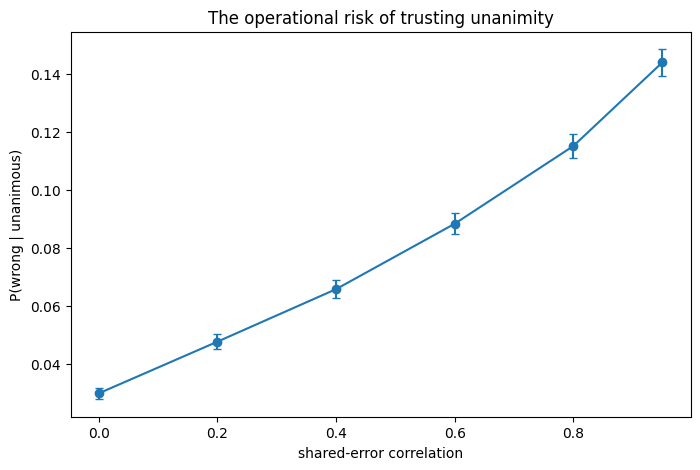

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    corr_conditional_summary["rho"],
    corr_conditional_summary["mean"],
    yerr=corr_conditional_summary["ci95"],
    marker="o",
    capsize=3,
)

plt.xlabel(
    "shared-error correlation"
)
plt.ylabel(
    "P(wrong | unanimous)"
)
plt.title(
    "The operational risk of trusting unanimity"
)
plt.show()


### Reading conditional false consensus

This is the more operational view.

Imagine that a supervisor or another coordination layer sees unanimous agreement and interprets it as a strong signal that the team is correct. The conditional metric asks how safe that assumption actually is.

As shared error grows, unanimity becomes a weaker certificate of correctness.

In a real multi-robot system, the shared cause could be a common perception model, a shared map, the same upstream sensor, similar training data, or the same environmental disturbance. The simulation does not tell us which cause is present. It shows why the dependency structure cannot be ignored.


## 10. Experiment 3: When stale sources are overconfident

Agents B and C are four steps behind. The team also has a moderate amount of shared observation error.

The observations themselves remain unchanged while I modify the uncertainty reported by B and C.

A calibration factor below `1.0` makes those stale sources appear more certain than the observation model justifies.

This is not a general test of every possible confidence model. It is a direct stress test of a rule that translates reported uncertainty into weight.


In [ ]:
cal_records = []

for factor in (
    1.5, 1.0, 0.8,
    0.6, 0.4, 0.25
):
    for run in range(N_RUNS):
        cfg = ExperimentConfig(
            regime_change=False,
            delays=(0, 4, 4),
            error_correlation=0.35,
            obs_noise=0.35,
            calibration_factors=(
                1.0,
                factor,
                factor,
            ),
            seed=(
                BASE_SEED
                + 2_000
                + run
            ),
        )

        strategy_metrics, _, _ = (
            run_once(cfg)
        )

        strategy_metrics[
            "calibration_factor"
        ] = factor
        strategy_metrics[
            "run"
        ] = run

        cal_records.append(
            strategy_metrics
        )

cal_df = pd.concat(
    cal_records,
    ignore_index=True,
)

cal_summary = summarize_ci(
    cal_df,
    [
        "calibration_factor",
        "strategy",
    ],
    "decision_accuracy",
)

display(cal_summary)


,calibration_factor,strategy,mean,count,std,ci95
0,0.25,freshest_random,0.864657,100,0.023205,0.004604
1,0.25,freshest_subset_mean,0.864757,100,0.023238,0.004611
2,0.25,inverse_variance,0.794386,100,0.036103,0.007164
3,0.25,majority_vote,0.823843,100,0.032654,0.006479
4,0.25,mean_all,0.848100,100,0.030627,0.006077
5,0.25,oracle_reliability,0.874114,100,0.027394,0.005436
6,0.40,freshest_random,0.864657,100,0.023205,0.004604
7,0.40,freshest_subset_mean,0.864757,100,0.023238,0.004611
8,0.40,inverse_variance,0.801986,100,0.035406,0.007025
9,0.40,majority_vote,0.823843,100,0.032654,0.006479


### Reading the calibration result

When the stale agents report calibrated uncertainty (`factor = 1.0`), inverse-variance fusion reaches about **0.848** decision accuracy.

When those same agents report only one quarter of their nominal uncertainty (`factor = 0.25`), inverse-variance accuracy falls to about **0.794**.

At that same setting:

- freshest-subset mean is around **0.865**;
- the privileged oracle reference is around **0.874**.

Nothing about the underlying observations improved when B and C became more confident. Only their reported uncertainty changed.

That is the key result:

> **Confidence becomes dangerous when the system interprets certainty as reliability without checking whether that certainty is calibrated.**

The other strategies remain largely insensitive to the calibration factor because they do not use reported uncertainty in their weighting rule.


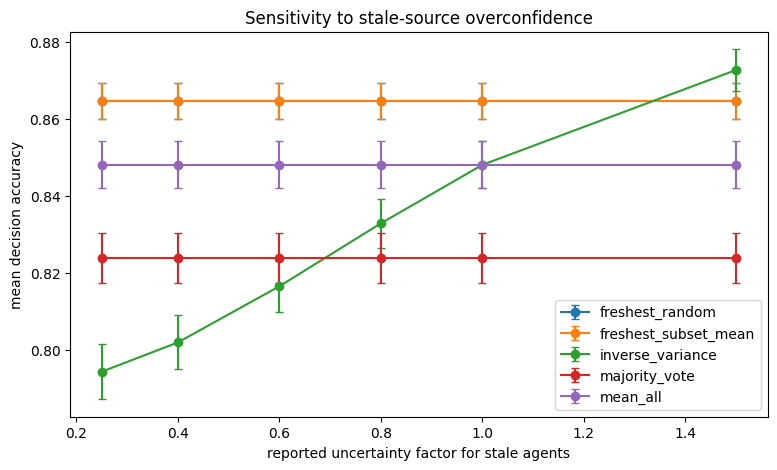

In [ ]:
deployable_cal = cal_summary[
    cal_summary["strategy"].isin([
        "mean_all",
        "freshest_random",
        "freshest_subset_mean",
        "inverse_variance",
        "majority_vote",
    ])
]

plt.figure(figsize=(9, 5))

for strategy in deployable_cal[
    "strategy"
].unique():
    subset = deployable_cal[
        deployable_cal["strategy"]
        == strategy
    ].sort_values(
        "calibration_factor"
    )

    plt.errorbar(
        subset[
            "calibration_factor"
        ],
        subset["mean"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=strategy,
    )

plt.xlabel(
    "reported uncertainty factor for stale agents"
)
plt.ylabel(
    "mean decision accuracy"
)
plt.title(
    "Sensitivity to stale-source overconfidence"
)
plt.legend()
plt.show()


### Reading the figure

The inverse-variance curve moves because this rule listens directly to reported uncertainty.

The other rules are intentionally much flatter. They are seeing exactly the same measurements; they simply do not reward a source for sounding more certain.

This makes the failure mechanism easy to isolate. The problem here is not stale information alone and it is not confidence alone. It is the interaction between stale information and a fusion rule that grants influence based on unverified confidence.


## 11. Experiment 4: A real change in environment dynamics

So far, disagreement has been created by information problems.

Now the environment itself changes.

Before the transition, the state is highly persistent. After the transition, old states become much less predictive of the next state. The process noise is adjusted so that the long-run variance remains approximately constant. The experiment is therefore changing temporal structure rather than simply making the post-change signal larger or smaller.

Agent A remains current. Agents B and C are five steps behind.

I compare the 150 steps immediately before the transition with the 150 steps immediately after it.


In [ ]:
def accuracy_in_window(
    estimate,
    x,
    threshold,
    start,
    end,
):
    return float(
        np.mean(
            (
                estimate[start:end]
                > threshold
            )
            == (
                x[start:end]
                > threshold
            )
        )
    )


regime_records = []

for run in range(N_RUNS):
    cfg = ExperimentConfig(
        regime_change=True,
        delays=(0, 5, 5),
        error_correlation=0.0,
        obs_noise=0.30,
        calibration_factors=(
            1.0, 1.0, 1.0
        ),
        seed=(
            BASE_SEED
            + 3_000
            + run
        ),
    )

    _, _, details = run_once(cfg)

    pre_start = (
        cfg.change_step - 150
    )
    pre_end = cfg.change_step

    post_start = cfg.change_step
    post_end = (
        cfg.change_step + 150
    )

    for (
        strategy,
        estimate,
    ) in details[
        "estimates"
    ].items():
        regime_records.append({
            "run": run,
            "strategy": strategy,
            "period": "before_change",
            "decision_accuracy": (
                accuracy_in_window(
                    estimate,
                    details["x"],
                    cfg.threshold,
                    pre_start,
                    pre_end,
                )
            ),
        })

        regime_records.append({
            "run": run,
            "strategy": strategy,
            "period": "after_change",
            "decision_accuracy": (
                accuracy_in_window(
                    estimate,
                    details["x"],
                    cfg.threshold,
                    post_start,
                    post_end,
                )
            ),
        })

    truth = (
        details["x"]
        > cfg.threshold
    ).astype(int)

    majority = details["majority"]

    regime_records.append({
        "run": run,
        "strategy": "majority_vote",
        "period": "before_change",
        "decision_accuracy": float(
            np.mean(
                majority[
                    pre_start:pre_end
                ]
                == truth[
                    pre_start:pre_end
                ]
            )
        ),
    })

    regime_records.append({
        "run": run,
        "strategy": "majority_vote",
        "period": "after_change",
        "decision_accuracy": float(
            np.mean(
                majority[
                    post_start:post_end
                ]
                == truth[
                    post_start:post_end
                ]
            )
        ),
    })

regime_df = pd.DataFrame(
    regime_records
)

regime_summary = summarize_ci(
    regime_df,
    ["period", "strategy"],
    "decision_accuracy",
)

display(regime_summary)


,period,strategy,mean,count,std,ci95
0,after_change,freshest_random,0.886867,100,0.028638,0.005682
1,after_change,freshest_subset_mean,0.886867,100,0.028638,0.005682
2,after_change,inverse_variance,0.650133,100,0.037730,0.007486
3,after_change,majority_vote,0.575800,100,0.041256,0.008186
4,after_change,mean_all,0.650133,100,0.037730,0.007486
5,after_change,oracle_reliability,0.805733,100,0.034126,0.006771
6,before_change,freshest_random,0.885267,100,0.045079,0.008945
7,before_change,freshest_subset_mean,0.885267,100,0.045079,0.008945
8,before_change,inverse_variance,0.851933,100,0.061863,0.012275
9,before_change,majority_vote,0.829333,100,0.067576,0.013409


### Reading the regime-change result

Before the change, the environment is highly persistent. A five-step-old observation is imperfect, but it still contains substantial information about the present.

After the change, that same five-step delay becomes more damaging because the environment moves away from its previous state more quickly.

For mean fusion, decision accuracy moves from about **0.852** before the transition to **0.650** after it.

For majority voting, it moves from about **0.829** to **0.576**.

The freshest-subset rule moves from about **0.885** to **0.887**.

This is a different failure from a broken sensor. B and C can be functioning exactly as designed. Their information has simply become less useful because the relationship between past and present has changed.

That distinction matters in adaptive systems. If the system interprets every sudden disagreement as a faulty agent, it can punish the only source that is correctly reflecting a new regime.


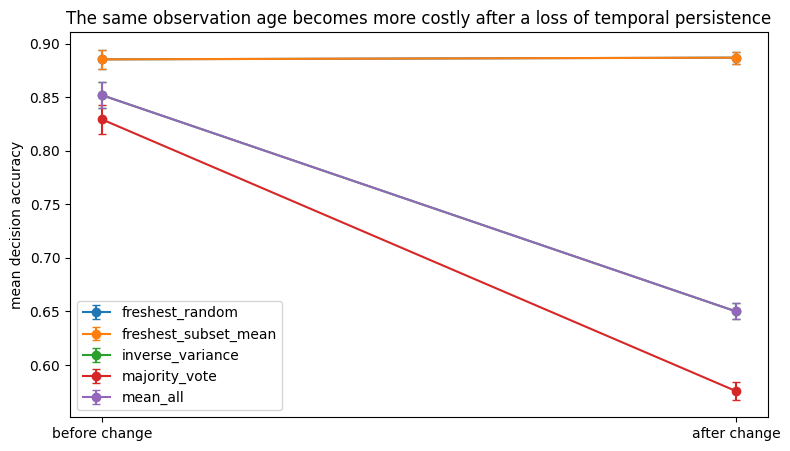

In [ ]:
deployable_regime = regime_summary[
    regime_summary["strategy"].isin([
        "mean_all",
        "freshest_random",
        "freshest_subset_mean",
        "inverse_variance",
        "majority_vote",
    ])
]

x_positions = {
    "before_change": 0,
    "after_change": 1,
}

plt.figure(figsize=(9, 5))

for strategy in deployable_regime[
    "strategy"
].unique():
    subset = deployable_regime[
        deployable_regime[
            "strategy"
        ] == strategy
    ]

    xs = [
        x_positions[p]
        for p in subset["period"]
    ]

    plt.errorbar(
        xs,
        subset["mean"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=strategy,
    )

plt.xticks(
    [0, 1],
    [
        "before change",
        "after change",
    ],
)
plt.ylabel(
    "mean decision accuracy"
)
plt.title(
    "The same observation age becomes more costly after a loss of temporal persistence"
)
plt.legend()
plt.show()


### Reading the transition figure

The delay has not changed. The sensors have not changed. The confidence reports have not changed.

What changed is the environment.

This is why disagreement cannot be interpreted only through source reliability. A source can become temporarily less useful without becoming defective, simply because the world has moved into a regime where old information decays faster.


## 12. Experiment 5: Combined stress

The last experiment combines the three information problems under a stationary environment.

The benign condition uses current observations, independent errors, and calibrated uncertainty.

The stressed condition gives B and C six-step-old observations, introduces strong shared error, and makes the stale sources overconfident.

Each scenario is evaluated over 100 trajectories.

The purpose is not to predict a real-world failure rate. It is to see how a rule that works under clean assumptions behaves when several of those assumptions fail at the same time.


In [ ]:
scenario_records = []
scenario_team_records = []

scenarios = {
    "benign": dict(
        regime_change=False,
        delays=(0, 0, 0),
        error_correlation=0.0,
        obs_noise=0.30,
        calibration_factors=(
            1.0, 1.0, 1.0
        ),
    ),
    "stressed": dict(
        regime_change=False,
        delays=(0, 6, 6),
        error_correlation=0.75,
        obs_noise=0.35,
        calibration_factors=(
            1.0, 0.40, 0.40
        ),
    ),
}

for (
    scenario,
    settings,
) in scenarios.items():
    for run in range(N_RUNS):
        cfg = ExperimentConfig(
            seed=(
                BASE_SEED
                + 4_000
                + run
            ),
            **settings,
        )

        (
            strategy_metrics,
            team_metrics,
            _,
        ) = run_once(cfg)

        strategy_metrics[
            "scenario"
        ] = scenario
        strategy_metrics[
            "run"
        ] = run

        scenario_records.append(
            strategy_metrics
        )

        scenario_team_records.append({
            "scenario": scenario,
            "run": run,
            **team_metrics,
        })

scenario_df = pd.concat(
    scenario_records,
    ignore_index=True,
)

scenario_team_df = pd.DataFrame(
    scenario_team_records
)

scenario_summary = summarize_ci(
    scenario_df,
    ["scenario", "strategy"],
    "decision_accuracy",
)

scenario_unanimity_summary = (
    summarize_ci(
        scenario_team_df,
        ["scenario"],
        "unanimity_rate",
    )
)

scenario_joint_summary = (
    summarize_ci(
        scenario_team_df,
        ["scenario"],
        "joint_false_consensus",
    )
)

scenario_conditional_summary = (
    summarize_ci(
        scenario_team_df,
        ["scenario"],
        "conditional_false_consensus",
    )
)

display(scenario_summary)
display(scenario_unanimity_summary)
display(scenario_joint_summary)
display(scenario_conditional_summary)


,scenario,strategy,mean,count,std,ci95
0,benign,freshest_random,0.883729,100,0.019911,0.003951
1,benign,freshest_subset_mean,0.929643,100,0.013942,0.002766
2,benign,inverse_variance,0.929643,100,0.013942,0.002766
3,benign,majority_vote,0.919286,100,0.015982,0.003171
4,benign,mean_all,0.929643,100,0.013942,0.002766
5,benign,oracle_reliability,0.929329,100,0.013489,0.002677
6,stressed,freshest_random,0.865214,100,0.022370,0.004439
7,stressed,freshest_subset_mean,0.865214,100,0.022322,0.004429
8,stressed,inverse_variance,0.767986,100,0.037007,0.007343
9,stressed,majority_vote,0.778800,100,0.035616,0.007067


,scenario,mean,count,std,ci95
0,benign,0.752757,100,0.036689,0.00728
1,stressed,0.674571,100,0.043544,0.00864


,scenario,mean,count,std,ci95
0,benign,0.012443,100,0.004533,0.000899
1,stressed,0.045614,100,0.010976,0.002178


,scenario,mean,count,std,ci95
0,benign,0.016678,100,0.006400,0.001270
1,stressed,0.068541,100,0.019362,0.003842


### Reading the combined stress result

Under the benign condition, inverse-variance fusion reaches about **0.930** decision accuracy.

Under the stressed condition, the same rule falls to about **0.768**. Freshest-subset mean reaches about **0.865** in that stressed setting.

The team-level consensus metrics change as well:

- unanimity moves from about **0.753** to **0.675**;
- joint false consensus moves from about **0.012** to **0.046**;
- conditional false consensus moves from about **0.017** to **0.069**.

The interesting part is not a single number. It is the change in ranking.

A rule that performs well when observations are current, errors are independent, and confidence is calibrated can become one of the weaker choices when those assumptions fail together.

That is exactly the kind of behaviour that a static reliability score cannot describe very well.


## 13. The same disagreement can mean completely different things

A superficial disagreement pattern does not tell us its cause.

Imagine that Agent A strongly disagrees with Agents B and C.

That same pattern can arise because:

- **Agent A has a faulty sensor.**
- **Agents B and C are operating on stale history.**
- **Agents B and C share a common-mode error.**
- **Agent A has detected a real change in the environment before the other two.**
- **The environment is in transition and none of the sources has clear epistemic authority yet.**

Those cases can look almost identical if the coordination layer only sees the current votes.

But they should not trigger the same response.

If A is faulty, reducing its influence may be correct.

If B and C are stale, suppressing A because it is in the minority can be exactly the wrong decision.

If B and C share the same error, their agreement should not be counted as two independent confirmations.

If A is the first source reflecting a real regime change, forcing immediate consensus can erase the signal the team most needs to preserve.

And if the whole environment is transitioning, the correct response may be to tolerate disagreement temporarily rather than manufacture certainty that the system does not actually have.


## 14. What I take from the experiment

The notebook does not show that consensus is harmful.

It shows something more precise.

**Agreement is conditional evidence.** Its value depends on how current the information is, how independent the sources really are, and whether the confidence attached to those sources deserves to be trusted.

**Redundancy is not automatically diversity.** Three agents can provide three observations while still sharing one underlying failure mode.

**Reliability is contextual.** The same healthy source can become less useful when its information is old or when the environment changes regime.

**Disagreement is not a diagnosis.** A minority source can be wrong, but it can also be the first source that is right.

That leaves a more interesting coordination problem than simply reaching consensus:

> **Should an autonomous team minimise disagreement, or should it first understand why its agents disagree?**

For me, that is the point where information fusion becomes an adaptive coordination problem.
